<a href="https://colab.research.google.com/github/edmilsondejesus/scrapy_extract/blob/main/stil2023_dashboard_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dashboard do Corpus STIL 2023

Este notebook para Google Colab importa o JSON dos artigos, agrega o corpus, calcula estatísticas textuais e exibe um dashboard com tabelas, gráficos e nuvem de palavras.

Requisitos atendidos:
- importar o corpus dos artigos
- tokenizar e quantificar
- não retirar stopwords
- quantidade de tokens e types
- quantidade de sentenças
- quantidade por classe gramatical
- quantidade de lemas
- top 10 palavras do corpus
- nuvem de palavras

In [ ]:
!pip install -q pandas plotly wordcloud matplotlib

## Etapa 1: carregar o arquivo JSON

Você pode subir o arquivo `stil2023_articles.json` gerado pelo scraper. Se preferir, também pode montar o Google Drive e apontar para o caminho do arquivo.

In [ ]:
import json
from pathlib import Path
from google.colab import files

uploaded = files.upload()
json_path = next(iter(uploaded.keys()))
print(f"Arquivo carregado: {json_path}")

Saving stil2023_articles_limpo.json to stil2023_articles_limpo.json
Arquivo carregado: stil2023_articles_limpo.json


## Etapa 2: importar bibliotecas e definir funções auxiliares

As funções abaixo fazem a leitura do corpus, a agregação dos campos e o cálculo das estatísticas.

In [ ]:
import json
import math
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import HTML, display
from wordcloud import WordCloud


WORD_RE = re.compile(r"\w", re.UNICODE)
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")


def load_articles(path: str):
    """Carrega o JSON de artigos produzido pelo scraper."""
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def sentence_count(text: str) -> int:
    """Conta sentenças de forma simples usando pontuação final."""
    text = (text or "").strip()
    if not text:
        return 0
    parts = [p.strip() for p in SENTENCE_SPLIT_RE.split(text) if p.strip()]
    return len(parts) if parts else 1


def is_word_token(token: str) -> bool:
    """Considera como palavra qualquer token com pelo menos um caractere alfanumérico."""
    return bool(WORD_RE.search(token or ""))


def build_corpus_stats(articles):
    """Agrega tokens, lemas, POS e sentenças do corpus inteiro."""
    all_tokens = []
    all_word_tokens = []
    all_pos = []
    all_lemmas = []
    sentence_total = 0
    full_texts = []

    for article in articles:
        text = article.get("artigo_completo", "") or ""
        tokens = article.get("artigo_tokenizado", []) or []
        pos_tags = article.get("pos_tagger", []) or []
        lemmas = article.get("lema", []) or []

        sentence_total += sentence_count(text)
        full_texts.append(text)
        all_tokens.extend(tokens)
        all_word_tokens.extend([token for token in tokens if is_word_token(token)])
        all_pos.extend(pos_tags)
        all_lemmas.extend([lemma for lemma in lemmas if is_word_token(lemma)])

    token_counter = Counter(all_word_tokens)
    pos_counter = Counter(all_pos)
    lemma_counter = Counter(all_lemmas)

    return {
        "articles": articles,
        "texts": full_texts,
        "all_tokens": all_tokens,
        "all_word_tokens": all_word_tokens,
        "all_pos": all_pos,
        "all_lemmas": all_lemmas,
        "sentence_total": sentence_total,
        "token_counter": token_counter,
        "pos_counter": pos_counter,
        "lemma_counter": lemma_counter,
        "token_total": len(all_word_tokens),
        "type_total": len(set(token.casefold() for token in all_word_tokens)),
        "lemma_total": len(set(lemma.casefold() for lemma in all_lemmas)),
    }


def top_words_df(stats, n=10):
    """Retorna o top N de palavras do corpus sem remover stopwords."""
    rows = []
    for token, freq in stats["token_counter"].most_common(n):
        rows.append({"palavra": token, "frequencia": freq})
    return pd.DataFrame(rows)


def pos_df(stats):
    """Retorna a distribuição de classes gramaticais."""
    rows = [{"classe_gramatical": tag, "frequencia": freq} for tag, freq in stats["pos_counter"].most_common()]
    return pd.DataFrame(rows)


def article_df(articles):
    """Cria uma tabela resumida por artigo."""
    rows = []
    for article in articles:
        rows.append({
            "titulo": article.get("titulo", ""),
            "idioma": article.get("idioma", ""),
            "tokens": len([t for t in article.get("artigo_tokenizado", []) if is_word_token(t)]),
            "types": len(set((t.casefold() for t in article.get("artigo_tokenizado", []) if is_word_token(t)))),
            "sentencas": sentence_count(article.get("artigo_completo", "") or ""),
            "lemmas": len(set((l.casefold() for l in article.get("lema", []) if is_word_token(l)))),
        })
    return pd.DataFrame(rows)


def make_summary_cards(stats, articles):
    """Exibe cartões HTML com os indicadores principais do corpus."""
    cards = [
        ("Artigos", len(articles)),
        ("Tokens", f"{stats['token_total']:,}"),
        ("Types", f"{stats['type_total']:,}"),
        ("Sentenças", f"{stats['sentence_total']:,}"),
        ("Lemmas", f"{stats['lemma_total']:,}"),
    ]

    html = """
    <div style='display:flex; gap:16px; flex-wrap:wrap; margin:16px 0;'>
    """
    for label, value in cards:
        html += f"""
        <div style='min-width:170px; padding:18px; border-radius:14px; background:#f4f7fb; border:1px solid #dbe4f0;'>
          <div style='font-size:14px; color:#4c5a67; margin-bottom:6px;'>{label}</div>
          <div style='font-size:28px; font-weight:700; color:#17324d;'>{value}</div>
        </div>
        """
    html += "</div>"
    display(HTML(html))


def plot_top_words(stats, n=10):
    """Plota o top N de palavras do corpus."""
    df = top_words_df(stats, n=n)
    fig = px.bar(df, x="palavra", y="frequencia", title=f"Top {n} palavras do corpus", text_auto=True)
    fig.update_layout(xaxis_title="Palavra", yaxis_title="Frequência")
    fig.show()


def plot_pos_distribution(stats):
    """Plota a distribuição das classes gramaticais."""
    df = pos_df(stats)
    fig = px.bar(df, x="classe_gramatical", y="frequencia", title="Quantidade por classe gramatical", text_auto=True)
    fig.update_layout(xaxis_title="Classe gramatical", yaxis_title="Frequência")
    fig.show()


def plot_article_tokens(articles):
    """Plota a quantidade de tokens por artigo."""
    df = article_df(articles).sort_values("tokens", ascending=False)
    fig = px.bar(df, x="titulo", y="tokens", title="Quantidade de tokens por artigo")
    fig.update_layout(xaxis_title="Artigo", yaxis_title="Tokens")
    fig.show()


def plot_wordcloud(stats):
    """Gera a nuvem de palavras a partir das frequências do corpus sem remover stopwords."""
    wc = WordCloud(width=1600, height=800, background_color="white", colormap="viridis")
    wc.generate_from_frequencies(stats["token_counter"])
    plt.figure(figsize=(18, 9))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Nuvem de palavras do corpus STIL 2023", fontsize=18)
    plt.show()


def render_dashboard(stats):
    """Renderiza o dashboard completo com indicadores, tabelas, gráficos e wordcloud."""
    articles = stats["articles"]
    make_summary_cards(stats, articles)
    display(top_words_df(stats, n=10))
    display(pos_df(stats))
    display(article_df(articles))
    plot_top_words(stats, n=10)
    plot_pos_distribution(stats)
    plot_article_tokens(articles)
    plot_wordcloud(stats)

## O que cada função faz

- `load_articles(path)`: lê o arquivo JSON e retorna a lista de artigos.
- `sentence_count(text)`: estima a quantidade de sentenças do texto.
- `is_word_token(token)`: filtra tokens para considerar apenas palavras, removendo pontuação isolada.
- `build_corpus_stats(articles)`: agrega o corpus inteiro e calcula os contadores principais.
- `top_words_df(stats, n)`: monta a tabela do top N palavras do corpus, sem retirar stopwords.
- `pos_df(stats)`: monta a tabela de frequência por classe gramatical.
- `article_df(articles)`: gera uma tabela resumida por artigo.
- `make_summary_cards(stats, articles)`: cria cartões com os indicadores centrais do corpus.
- `plot_top_words(stats, n)`: desenha o gráfico do top N palavras.
- `plot_pos_distribution(stats)`: desenha o gráfico das classes gramaticais.
- `plot_article_tokens(articles)`: mostra a distribuição de tokens por artigo.
- `plot_wordcloud(stats)`: gera a nuvem de palavras do corpus.
- `render_dashboard(stats)`: junta tudo e renderiza o dashboard completo.

## Etapa 3: construir o corpus agregado

In [ ]:
articles = load_articles(json_path)


stats = build_corpus_stats(articles)

print(f"Artigos carregados: {len(articles)}")
print(f"Tokens: {stats['token_total']}")
print(f"Types: {stats['type_total']}")
print(f"Sentenças: {stats['sentence_total']}")
print(f"Lemmas: {stats['lemma_total']}")

Artigos carregados: 30
Tokens: 75366
Types: 11647
Sentenças: 3547
Lemmas: 9719


## Etapa 4: renderizar o dashboard

,palavra,frequencia
0,de,4343
1,a,1774
2,e,1771
3,o,1403
4,que,1203
5,em,1016
6,do,939
7,para,842
8,da,787
9,com,620


,classe_gramatical,frequencia
0,NOUN,18930
1,PUNCT,14005
2,ADP,13600
3,PROPN,9185
4,VERB,8082
5,DET,7081
6,ADJ,5704
7,NUM,4295
8,ADV,2453
9,CCONJ,2214


,titulo,idioma,tokens,types,sentencas,lemmas
0,A funcionalidade dos adjetivos em dois gêneros...,Português,3489,1013,158,853
1,Abordagens Baseadas em Léxicos para a Classifi...,Português,1834,675,88,592
2,Anotacão do Dataset Multimodal da ReINVenTA,Português,1117,599,57,552
3,Aposicões anafóricas e catafóricas no portuguê...,Português,3205,1000,155,816
4,Aryon: um aplicativo Shiny para documentacão e...,Português,1091,487,49,431
5,Avaliacão do senso comum em modelos de linguag...,Português,1587,671,74,587
6,Características gerais das leis federais brasi...,Português,3400,1154,118,950
7,CDJUR-BR - Uma Colecão Dourada do Judiciário B...,Português,3393,1223,150,1056
8,Classificacão de gêneros a partir de letras de...,Português,3727,1364,150,1199
9,Classificacão de Polaridade Orientada aos Alvo...,Português,3697,1152,159,996


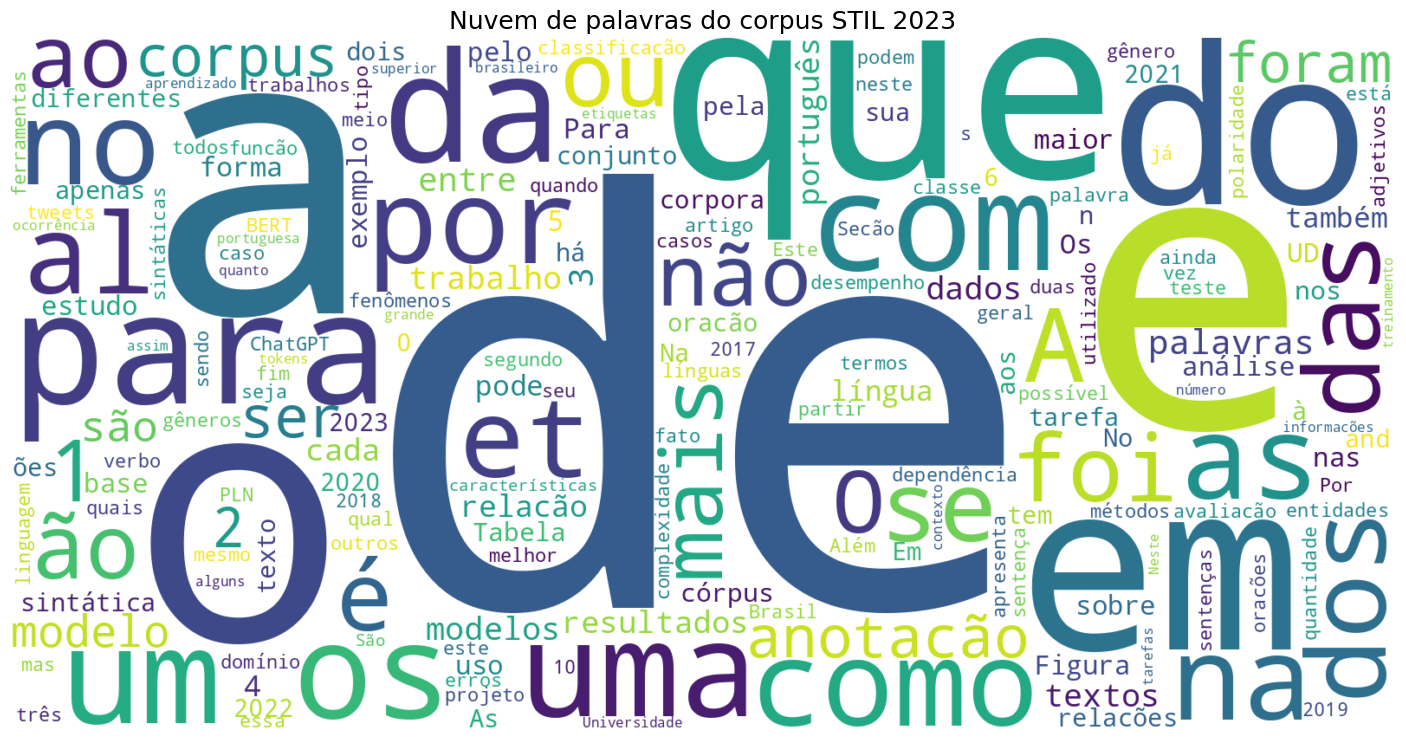

In [ ]:
render_dashboard(stats)

## Etapa 5: exportar as tabelas, se quiser

Estas células salvam as estatísticas em CSV para download posterior.

In [ ]:
top_words_df(stats, n=10).to_csv("top10_palavras.csv", index=False, encoding="utf-8")
pos_df(stats).to_csv("classes_gramaticais.csv", index=False, encoding="utf-8")
article_df(articles).to_csv("estatisticas_por_artigo.csv", index=False, encoding="utf-8")

print("Arquivos CSV gerados com sucesso.")

Arquivos CSV gerados com sucesso.


## Etapa 6: Análise de Bigramas e Trigramas

Esta etapa instala o NLTK, clacula as estatísticas de n-gramas (frequência, matrizes, top 20) e salva os resultados em CSV

In [ ]:
# Instala e importa as bibliotecas necessárias
!pip install -q nltk
import nltk
from nltk import bigrams, trigrams
from nltk.probability import FreqDist, ConditionalFreqDist
from collections import Counter
import pandas as pd
import re

# Faz o download dos dados necessários do NLTK
# O 'punkt' é o recurso básico de tokenização
# O 'punkt_tab' é a versão mais recente exigida pela versão atual do NLTK
print("Baixando recursos do NLTK...")
nltk.download('punkt')
nltk.download('punkt_tab')
print("Recursos baixados com sucesso!")

Baixando recursos do NLTK...


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Recursos baixados com sucesso!


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
def fix_broken_words(text: str) -> str:
    """
    Corrige palavras que foram quebradas com espaço em branco indevido.
    Ex: "n ão" -> "não", "c aracterísticas" -> "características"
    """
    if not text:
        return text

    # Padrões comuns de palavras quebradas
    replacements = [
        (r'\bn\s+ã\s*o\b', 'não'),           # n ão -> não
        (r'\bn\s+a\s*o\b', 'nao'),           # n a o -> nao
        (r'\bn\s+ã\s*o\b', 'não'),           # n ã o -> não
        (r'\bn\s+a\s+o\b', 'nao'),           # n a o -> nao
        (r'\bc\s+a\s+r\s+a\s+c\s+t\s+e\s+r\s+í\s+s\s+t\s+i\s+c\s+a\b', 'característica'),
        (r'\bc\s+a\s+r\s+a\s+c\s+t\s+e\s+r\s+í\s+s\s+t\s+i\s+c\s+o\b', 'característico'),
        (r'\bd\s+i\s+f\s+e\s+r\s+e\s+n\s+ç\s+a\b', 'diferença'),
        (r'\bp\s+r\s+o\s+p\s+o\s+s\s+i\s+ç\s+ã\s+o\s+', 'proposição'),
        (r'\ba\s+n\s+á\s+l\s+i\s+s\s+e\s+', 'análise'),
        (r'\ba\s+v\s+a\s+l\s+i\s+a\s+ç\s+ã\s+o\s+', 'avaliação'),
        (r'\bi\s+n\s+f\s+o\s+r\s+m\s+a\s+ç\s+ã\s+o\s+', 'informação'),
        (r'\bp\s+r\s+o\s+c\s+e\s+s\s+s\s+a\s+m\s+e\s+n\s+t\s+o\s+', 'processamento'),
        (r'\bl\s+i\s+n\s+g\s+u\s+a\s+g\s+e\s+m\s+', 'linguagem'),
    ]

    for pattern, replacement in replacements:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    # Correção genérica: remove espaços entre letras que estão separadas
    # Isso resolve casos como "v a r i a ç ã o" -> "variação"
    # Mas cuidado para não afetar palavras normais
    def fix_generic_spaces(match):
        word = match.group(0)
        # Remove espaços apenas se a palavra for curta (menos de 20 chars)
        # e tiver muitos espaços (possivelmente quebrada)
        if len(word) < 30 and word.count(' ') > len(word) * 0.3:
            return word.replace(' ', '')
        return word

    # Aplica correção genérica apenas em palavras suspeitas
    text = re.sub(r'\b[A-Za-záàâãéèêíïóôõúç\s]{4,30}\b', fix_generic_spaces, text, flags=re.IGNORECASE)

    return text
# Função para preparar o texto: tokenizar em palavras (minúsculas) e filtrar pontuação
def preparar_texto(texto):
    """
    Tokeniza o texto usando NLTK com suporte a português.
    Remove pontuação e converte para minúsculas.
    """
    # Tenta usar o tokenizador específico para português
    tokens = nltk.word_tokenize(texto, language='portuguese')

    # Converte para minúsculas e filtra tokens que são apenas pontuação ou números
    tokens_limpos = [token.lower() for token in tokens if token.isalnum() and not token.isdigit()]
    return tokens_limpos

# Aplica o pré-processamento a todos os textos do corpus
print("Processando os artigos do corpus...")
tokens_corpus = []
for i, artigo in enumerate(articles):
    texto_completo = artigo.get('artigo_completo', '')
    if texto_completo:
        texto_completo = fix_broken_words(texto_completo)
        tokens_artigo = preparar_texto(texto_completo)
        tokens_corpus.extend(tokens_artigo)
    # Mostra progresso a cada 10 artigos
    if (i + 1) % 10 == 0:
        print(f"  Processados {i+1} de {len(articles)} artigos...")

print(f"\nTotal de tokens (palavras) processados: {len(tokens_corpus):,}")
print(f"Total de palavras únicas (types): {len(set(tokens_corpus)):,}")

Processando os artigos do corpus...
  Processados 10 de 30 artigos...
  Processados 20 de 30 artigos...
  Processados 30 de 30 artigos...

Total de tokens (palavras) processados: 68,754
Total de palavras únicas (types): 9,223


In [ ]:
# Função para criar e exibir a matriz de frequência de n-gramas
# Função para criar e exibir a matriz de frequência de n-gramas (VERSÃO CORRIGIDA)
def analisar_ngramas(tokens, n, nome_ngrama):
    """
    Gera a matriz de frequência (FreqDist) e a condicional (ConditionalFreqDist)
    para os n-gramas. Exibe o TOP 10 e prepara os dados para CSV.
    """
    print(f"\n--- Análise de {nome_ngrama}s ---")

    # Gera a lista de n-gramas
    print(f"Gerando {nome_ngrama}s...")
    n_gramas = list(nltk.ngrams(tokens, n))
    print(f"Total de {nome_ngrama}s gerados: {len(n_gramas):,}")  # <--- CORREÇÃO AQUI: nome_ngrama

    # 1. Frequência absoluta (para o CSV e TOP 20)
    freq_absoluta = FreqDist(n_gramas)

    # Exibe o TOP 20
    print(f"\nTOP 20 {nome_ngrama}s mais frequentes:")
    for ngram, freq in freq_absoluta.most_common(20):
        print(f'  {" ".join(ngram)}: {freq}')

    # 2. Matriz de frequência condicional (para previsão)
    print(f"Construindo matriz condicional para {nome_ngrama}s...")
    cond_freq = ConditionalFreqDist()
    for ngram in n_gramas:
        contexto = ngram[:-1]  # Último item é a palavra alvo
        palavra_alvo = ngram[-1]
        cond_freq[contexto][palavra_alvo] += 1

    print(f"Contextos únicos encontrados: {len(cond_freq.conditions()):,}")

    # Salva a frequência absoluta em CSV
    df_freq = pd.DataFrame(freq_absoluta.items(), columns=[f'{nome_ngrama}', 'frequencia'])
    df_freq = df_freq.sort_values('frequencia', ascending=False)
    nome_arquivo = f'frequencia_{nome_ngrama}s.csv'
    df_freq.to_csv(nome_arquivo, index=False, encoding='utf-8-sig')
    print(f"\nArquivo '{nome_arquivo}' salvo com {len(df_freq):,} linhas.")

    return freq_absoluta, cond_freq

# Executa a análise para Bigramas e Trigramas
print("\n" + "="*50)
print("INICIANDO ANÁLISE DE N-GRAMAS")
print("="*50)

freq_bigramas, cond_bigramas = analisar_ngramas(tokens_corpus, 2, 'bigrama')
freq_trigramas, cond_trigramas = analisar_ngramas(tokens_corpus, 3, 'trigrama')


INICIANDO ANÁLISE DE N-GRAMAS

--- Análise de bigramas ---
Gerando bigramas...
Total de bigramas gerados: 68,753

TOP 20 bigramas mais frequentes:
  et al: 372
  para o: 157
  para a: 146
  que o: 115
  de um: 106
  de anotacão: 96
  e o: 92
  com a: 88
  com o: 85
  de uma: 85
  o modelo: 81
  e a: 77
  de dados: 76
  que a: 72
  os resultados: 71
  por exemplo: 70
  de palavras: 69
  em português: 66
  pode ser: 66
  que se: 62
Construindo matriz condicional para bigramas...
Contextos únicos encontrados: 9,223

Arquivo 'frequencia_bigramas.csv' salvo com 39,524 linhas.

--- Análise de trigramas ---
Gerando trigramas...
Total de trigramas gerados: 68,752

TOP 20 trigramas mais frequentes:
  et al e: 42
  para o português: 36
  de acordo com: 28
  uma vez que: 28
  a partir de: 28
  o corpus de: 26
  o uso de: 25
  relacões de dependência: 24
  a tarefa de: 24
  por meio de: 23
  de são paulo: 23
  a fim de: 23
  em relacão ao: 22
  de inteligência artificial: 22
  base de dados: 21
 

## Etapa 7: Função para Prever a Próxima Palavra

Prevê a próxima palavra baseada na frequência de bigramas ou trigramas.  Exibe a palavra e sua probabilidade.


In [ ]:
def prever_proxima_palavra(frase, modelo, cond_freq, tipo_modelo):
    """
    Prevê a próxima palavra baseada na frequência de bigramas ou trigramas.
    Exibe a palavra e sua probabilidade.

    Parâmetros:
    - frase: string com a frase do usuário
    - modelo: 'bigrama' ou 'trigrama' (não usado diretamente, mas mantido para consistência)
    - cond_freq: ConditionalFreqDist do modelo correspondente
    - tipo_modelo: 'bigrama' ou 'trigrama' (usado para decisões)

    Retorna:
    - Tupla (palavra_prevista, probabilidade) ou (None, None) se não encontrar
    """
    # Prepara a frase de entrada
    tokens_frase = preparar_texto(frase)
    if not tokens_frase:
        print("Frase inválida ou vazia.")
        return None, None

    # Determina o contexto baseado no modelo
    if tipo_modelo == 'bigrama':
        if len(tokens_frase) < 1:
            print(f"Para bigramas, a frase precisa ter pelo menos 1 palavra. A frase '{frase}' tem {len(tokens_frase)}.")
            return None, None
        contexto = (tokens_frase[-1],)  # Última palavra é a chave no bigrama
        nome_modelo = "Bigrama"
    elif tipo_modelo == 'trigrama':
        if len(tokens_frase) < 2:
            print(f"Para trigramas, a frase precisa ter pelo menos 2 palavras. A frase '{frase}' tem {len(tokens_frase)}.")
            return None, None
        contexto = tuple(tokens_frase[-2:])  # Tupla das duas últimas palavras
        nome_modelo = "Trigrama"
    else:
        print("Modelo inválido. Escolha 'bigrama' ou 'trigrama'.")
        return None, None

    # Verifica se o contexto existe no modelo
    if contexto not in cond_freq:
        print(f"\n{nome_modelo} - Contexto '{' '.join(contexto)}' não encontrado no corpus para a frase: '{frase}'.")
        return None, None

    # Obtém as frequências das palavras para esse contexto
    palavra_freq = cond_freq[contexto]
    total_ocorrencias = sum(palavra_freq.values())

    # Encontra a palavra mais provável
    palavra_mais_provavel = palavra_freq.max()
    probabilidade = (palavra_freq[palavra_mais_provavel] / total_ocorrencias) * 100

    # Exibe o resultado
    print(f"\n--- Previsão com {nome_modelo} ---")
    print(f"Frase: {frase} -> {palavra_mais_provavel}")
    print(f"Probabilidade (frequência relativa): {probabilidade:.2f}% com {total_ocorrencias} ocorrências no corpus.")
    return palavra_mais_provavel, probabilidade

In [ ]:
# Frases de exemplo
frases_exemplo = [
    "A semântica é",
    "A história do LLM teve início",
    "algoritmos capazes de",
    "análise de tokens",
    "processamento de linguagem"
]

print("\n" + "="*60)
print("DEMONSTRAÇÃO DE PREVISÃO DE PRÓXIMA PALAVRA")
print("="*60)

for frase in frases_exemplo:
    print(f"\n{'='*40}")
    print(f"Analisando a frase: '{frase}'")
    print('='*40)

    # Previsão com Bigrama
    prever_proxima_palavra(frase, 'bigrama', cond_bigramas, 'bigrama')

    # Previsão com Trigrama
    prever_proxima_palavra(frase, 'trigrama', cond_trigramas, 'trigrama')


DEMONSTRAÇÃO DE PREVISÃO DE PRÓXIMA PALAVRA

Analisando a frase: 'A semântica é'

--- Previsão com Bigrama ---
Frase: A semântica é -> o
Probabilidade (frequência relativa): 9.12% com 318 ocorrências no corpus.

Trigrama - Contexto 'semântica é' não encontrado no corpus para a frase: 'A semântica é'.

Analisando a frase: 'A história do LLM teve início'

--- Previsão com Bigrama ---
Frase: A história do LLM teve início -> da
Probabilidade (frequência relativa): 40.00% com 5 ocorrências no corpus.

Trigrama - Contexto 'teve início' não encontrado no corpus para a frase: 'A história do LLM teve início'.

Analisando a frase: 'algoritmos capazes de'

--- Previsão com Bigrama ---
Frase: algoritmos capazes de -> um
Probabilidade (frequência relativa): 2.44% com 4346 ocorrências no corpus.

--- Previsão com Trigrama ---
Frase: algoritmos capazes de -> analisar
Probabilidade (frequência relativa): 30.00% com 10 ocorrências no corpus.

Analisando a frase: 'análise de tokens'

--- Previsão com B

## Etapa 8: Predição de textos longos

Esta etapa permite gerar textos automaticamente a partir de uma semente (frase inicial) usando o modelo de bigramas ou trigramas treinado no corpus do STIL 2023.

O texto gerado é automaticamente formatado com:
- Primeira letra maiúscula
- Ponto final ao término da frase

In [ ]:
import math
import random

def calcular_perplexidade(texto, cond_freq, n):
    tokens = preparar_texto(texto)
    if len(tokens) < n:
        return float('inf')

    log_prob = 0
    total = 0

    for i in range(len(tokens) - n + 1):
        if n == 2:
            contexto = (tokens[i],)
            alvo = tokens[i+1]
        else:
            contexto = (tokens[i], tokens[i+1])
            alvo = tokens[i+2]

        if contexto in cond_freq:
            freq = cond_freq[contexto].get(alvo, 0)
            total_ctx = sum(cond_freq[contexto].values())
            prob = (freq + 1) / (total_ctx + len(cond_freq[contexto]))
        else:
            prob = 1 / len(cond_freq)

        log_prob += math.log(prob)
        total += 1

    return math.exp(-log_prob / total) if total > 0 else float('inf')

def prever_texto_longos(semente, modelo_ngramas, tamanho_max=50):
    cond_freq = cond_bigramas if modelo_ngramas == 'bigrama' else cond_trigramas
    n = 2 if modelo_ngramas == 'bigrama' else 3

    tokens = preparar_texto(semente)
    if not tokens:
        return semente, None

    for _ in range(tamanho_max):
        if modelo_ngramas == 'bigrama':
            if len(tokens) < 1: break
            contexto = (tokens[-1],)
        else:
            if len(tokens) < 2: break
            contexto = tuple(tokens[-2:])

        if contexto not in cond_freq:
            break

        palavras = list(cond_freq[contexto].keys())
        pesos = list(cond_freq[contexto].values())
        tokens.append(random.choices(palavras, weights=pesos, k=1)[0])

    texto = ' '.join(tokens)
    texto = texto[0].upper() + texto[1:] + ('' if texto[-1] in '.!?' else '.')

    perplexidade = calcular_perplexidade(texto, cond_freq, n)
    return texto, perplexidade

In [ ]:
# Gerar com bigrama
texto, perp = prever_texto_longos("inteligência artificial", "bigrama", 100)
print(f"Texto: {texto}")
print(f"Perplexidade: {perp:.2f}")

# Gerar com trigrama
texto, perp = prever_texto_longos("o processamento de linguagem", "trigrama", 100)
print(f"Texto: {texto}")
print(f"Perplexidade: {perp:.2f}")

Texto: Inteligência artificial da idade gênero no domínio geral que apresenta para exemplificar a sua linguagem humana e além de bilh ão exemplos prévios da métrica diagnosticados controle média das sentenças anotadas como e v oz passiva também houve casos ambíguos incluem discuss ões e antecipado pela maioria dos datasets como já o mesmo episódio procurando na criacão de reconhecimento de dependências sintáticas em português para enhanced dependencies ud o desempenho em aprendizado profundo deep learning bengio et al ele acabou de cinco funcões sintáticas além disso o qual nosso corpus base em grandes desafios que podem ocupar qualquer uldo banco de aparecimento.
Perplexidade: 22.90
Texto: O processamento de linguagem natural todos os tweets têm no máximo caracteres quanto à estrutura o corpus também tabela acurácia para a construcão de tweebanks autores como sanguinetti et al todos estes trabalhos utilizam algum tipo de variacão e registro cbvr berber sardinha 2013a materiais e métod

Etapa 9:  Treinar o Word2vec com o algoritmo skipgram para os dados dos artigos.

Atividades que devem ser respondidas:

1) Vetores gerados para as palavras:
 a) modelos
 b) linguagem
 c) substantivo de maior frequencia do seu corpus
 d) verbo de maior frequencia do seu corpus

2) Quais termos são mais similares aos termos:
 a) modelos
 b) linguagem
 c) substantivo de maior frequencia do seu corpus
 d) verbo de maior frequencia do seu corpus

3) fazer soma e subtração de vetores para dar outro vetor de resultado, com o Word2vec pretreinado e o Word2vec com os seus dados dos artigos

In [ ]:
# ==========================================
# Etapa 9: Treinamento e Análise com Word2Vec
# ==========================================

!pip install -q gensim

import gensim
from gensim.models import Word2Vec  # Modelo Word2Vec para gerar vetores de palavras
from collections import Counter      # Contador para frequência de palavras
import numpy as np                   # Operações numéricas com vetores
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)  # Suprime avisos de deprecated



# --- Etapa 9.1: Preparação dos dados para o Word2Vec ---
print("Objetivo: Transformar os artigos tokenizados em sentenças para treinar o Word2Vec.")

sentencas_para_w2v = []  # Lista que armazenará cada artigo como uma lista de tokens

for artigo in articles:  # Percorre cada artigo do corpus
    tokens_artigo = artigo.get('artigo_tokenizado', [])  # Obtém a lista de tokens do artigo
    if tokens_artigo:  # Verifica se o artigo possui tokens
        sentencas_para_w2v.append(tokens_artigo)  # Adiciona os tokens à lista de sentenças

print(f"   Total de documentos processados: {len(sentencas_para_w2v)}")
print(f"   Exemplo (primeiros 15 tokens do primeiro artigo):")
print(f"   {sentencas_para_w2v[0][:15]}")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 12.6 MB/s eta 0:00:00
Objetivo: Transformar os artigos tokenizados em sentenças para treinar o Word2Vec.
   Total de documentos processados: 30
   Exemplo (primeiros 15 tokens do primeiro artigo):
   ['A', 'funcionalidade', 'dos', 'adjetivos', 'em', 'dois', 'gêneros', 'discursivos', ':', 'uma', 'investigacão', 'com', 'base', 'nas', 'dependências']


In [ ]:
# --- Etapa 9.2: Treinamento do modelo Word2Vec com skip-gram ---
print("Objetivo: Treinar um modelo Skip-gram para gerar vetores de palavras.")

# Cria e treina o modelo Word2Vec com os parâmetros definidos
modelo_w2v = Word2Vec(
    sentences=sentencas_para_w2v,  # Lista de sentenças para treinamento
    vector_size=100,               # Dimensão dos vetores (100 números por palavra)
    window=5,                      # Número de palavras antes/depois da palavra alvo
    min_count=5,                   # Ignora palavras que aparecem menos de 5 vezes
    workers=4,                     # Número de threads para paralelização
    sg=1,                          # 1 = skip-gram, 0 = CBOW (skip-gram é melhor para corpus pequeno)
    epochs=10,                     # Número de passadas completas sobre o corpus
    seed=42                        # Semente para reproducibilidade dos resultados
)

print(f"\n   RESULTADO: Modelo treinado com sucesso!")
print(f"   - Tamanho do vocabulário: {len(modelo_w2v.wv)} palavras")
print(f"   - Dimensão dos vetores: {modelo_w2v.wv.vector_size}")


# --- Etapa 9.3: Estatísticas básicas do corpus ---
print("Objetivo: Identificar o substantivo e o verbo mais frequentes no corpus.")

todos_substantivos = []  # Lista para acumular todos os substantivos
todos_verbos = []        # Lista para acumular todos os verbos

# Percorre cada artigo do corpus
for artigo in articles:
    tokens = artigo.get('artigo_tokenizado', [])  # Obtém os tokens do artigo
    pos_tags = artigo.get('pos_tagger', [])       # Obtém as POS tags do artigo

    # Percorre cada token e sua respectiva POS tag simultaneamente
    for token, pos in zip(tokens, pos_tags):  # zip combina duas listas em pares
        if pos == 'NOUN':                     # Verifica se é um substantivo
            todos_substantivos.append(token.lower())  # Adiciona o token em minúsculo
        elif pos == 'VERB':                   # Verifica se é um verbo
            todos_verbos.append(token.lower())       # Adiciona o token em minúsculo

# Calcula o substantivo mais frequente
if todos_substantivos:  # Verifica se a lista não está vazia
    contagem_substantivos = Counter(todos_substantivos)  # Cria contador de frequências
    substantivo_top = contagem_substantivos.most_common(1)[0]  # Pega o mais comum (1º elemento)
    print(f"\n   RESULTADO - Substantivo mais frequente:")
    print(f"   - Palavra: '{substantivo_top[0]}'")
    print(f"   - Frequência: {substantivo_top[1]} ocorrências")
else:  # Caso não haja substantivos no corpus
    substantivo_top = ("dados", 0)  # Valor padrão
    print("\n   Nenhum substantivo encontrado no corpus.")

# Calcula o verbo mais frequente
if todos_verbos:  # Verifica se a lista não está vazia
    contagem_verbos = Counter(todos_verbos)  # Cria contador de frequências
    verbo_top = contagem_verbos.most_common(1)[0]  # Pega o mais comum (1º elemento)
    print(f"\n   RESULTADO - Verbo mais frequente:")
    print(f"   - Palavra: '{verbo_top[0]}'")
    print(f"   - Frequência: {verbo_top[1]} ocorrências")
else:  # Caso não haja verbos no corpus
    verbo_top = ("ser", 0)  # Valor padrão
    print("\n   Nenhum verbo encontrado no corpus.")

Objetivo: Treinar um modelo Skip-gram para gerar vetores de palavras.

   RESULTADO: Modelo treinado com sucesso!
   - Tamanho do vocabulário: 2194 palavras
   - Dimensão dos vetores: 100
Objetivo: Identificar o substantivo e o verbo mais frequentes no corpus.

   RESULTADO - Substantivo mais frequente:
   - Palavra: 'anotacão'
   - Frequência: 247 ocorrências

   RESULTADO - Verbo mais frequente:
   - Palavra: 'pode'
   - Frequência: 127 ocorrências


In [ ]:
# --- Etapa 9.4: Funções auxiliares ---
print("Definindo funções para exibir vetores e encontrar palavras similares.")

def mostrar_vetor(modelo, palavra, n_dimensoes=10):
    """
    Exibe as primeiras n dimensões do vetor de uma palavra.

    Parâmetros:
    - modelo: modelo Word2Vec treinado
    - palavra: string com a palavra a ser consultada
    - n_dimensoes: número de dimensões a serem exibidas (padrão 10)
    """
    try:
        vetor = modelo.wv[palavra]  # Acessa o vetor da palavra no modelo (atributo wv = word vectors)
        print(f"   Vetor de '{palavra}' (primeiras {n_dimensoes} dimensões):")
        print(f"   {np.round(vetor[:n_dimensoes], 4)}")  # Arredonda para 4 casas decimais
        print(f"   Norma do vetor (comprimento): {np.linalg.norm(vetor):.4f}")  # Calcula a norma L2
        return vetor
    except KeyError:  # Exceção lançada quando a palavra não está no vocabulário
        print(f"   ERRO: Palavra '{palavra}' não encontrada no vocabulário.")
        return None

def palavras_similares(modelo, palavra, n=10):
    """
    Retorna as n palavras mais similares a uma dada palavra.

    Parâmetros:
    - modelo: modelo Word2Vec treinado
    - palavra: string com a palavra a ser consultada
    - n: número de palavras similares a retornar (padrão 10)
    """
    try:
        # most_similar retorna lista de tuplas (palavra, similaridade_cosseno)
        return modelo.wv.most_similar(palavra, topn=n)
    except KeyError:  # Exceção lançada quando a palavra não está no vocabulário
        print(f"   ERRO: Palavra '{palavra}' não encontrada no vocabulário.")
        return None

# ==========================================
# Funcao para visualizacao de vizinhos com PCA
# ==========================================

from sklearn.decomposition import PCA

def plotar_vizinhos(modelo, palavra, topn=20, titulo=None):
    # 1. Verifica se a palavra existe no vocabulario
    if palavra not in modelo.wv:
        print(f"A palavra '{palavra}' nao esta no vocabulario.")
        return

    # 2. Coleta a palavra alvo e seus vizinhos mais similares
    #    Ex: palavra = "linguagem"
    #    vizinhos = ["linguagem", "processamento", "texto", "corpus", ...]
    vizinhos = [palavra] + [w for w, _ in modelo.wv.most_similar(palavra, topn=topn)]

    # 3. Obtem os vetores de 100 dimensoes para cada palavra
    #    Cada vetor e uma lista de 100 numeros
    vetores = [modelo.wv[w] for w in vizinhos]

    # 4. Reduz de 100 dimensoes para 2 dimensoes usando PCA
    #    O PCA encontra os 2 eixos mais importantes que preservam as distancias
    coords = PCA(n_components=2, random_state=42).fit_transform(vetores)

    # 5. Plota os pontos no plano 2D
    #    Pontos proximos = palavras semanticamente similares
    #    Pontos distantes = palavras menos relacionadas
    plt.figure(figsize=(12, 8))
    plt.scatter(coords[:, 0], coords[:, 1], s=100, alpha=0.7)

    # 6. Adiciona rotulos (nomes das palavras)
    for i, token in enumerate(vizinhos):
        plt.annotate(token, (coords[i, 0], coords[i, 1]))

    plt.title(titulo or f"Vizinhos de '{palavra}'")
    plt.show()

Definindo funções para exibir vetores e encontrar palavras similares.


Descrição: O Word2Vec representa cada palavra como um vetor numérico.
Palavras com significados semelhantes têm vetores próximos no espaço.

   Modelo Word2Vec treinado (parâmetros):
   - Algoritmo: Skip-gram
   - Dimensão dos vetores: 100
   - Tamanho do vocabulário: 2194 palavras
   - Janela de contexto: 5 palavras
   - Frequência mínima: 5 ocorrências

   Exemplo de vetor para a palavra 'modelos':
   Vetor de 'modelos' (primeiras 10 dimensões):
   [-0.028  -0.0931 -0.3201  0.4547  0.1707 -0.0221 -0.1696  0.1932 -0.0056
  0.6597]
   Norma do vetor (comprimento): 2.9992





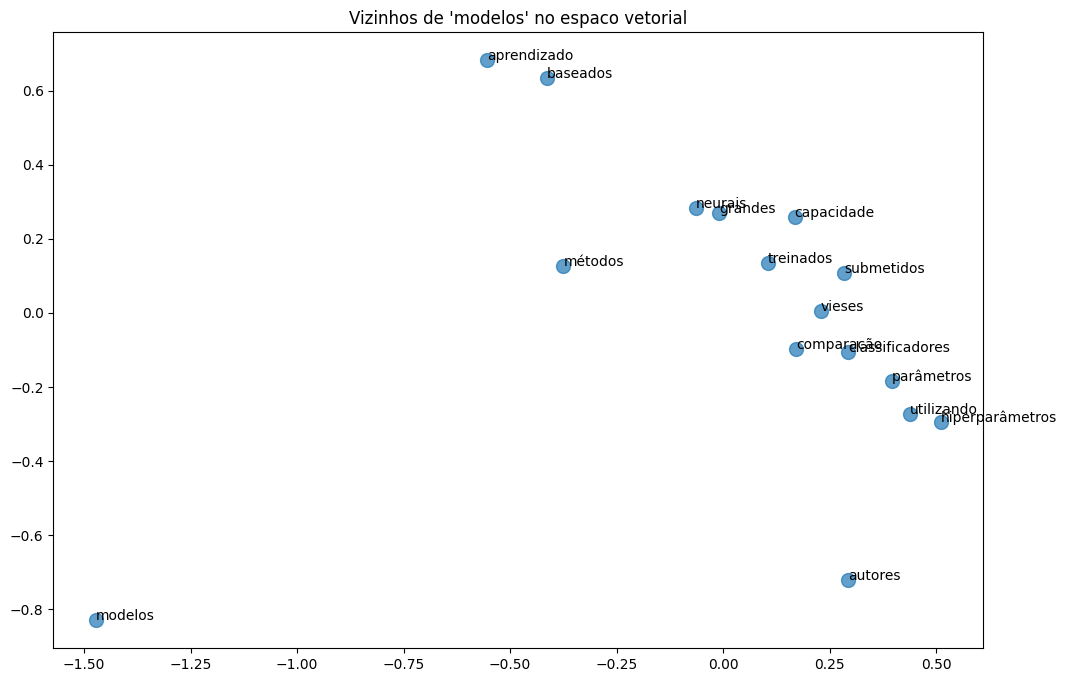


   Explicação: Cada vetor tem 100 dimensões. As primeiras 10 dimensões
   são mostradas acima. A norma indica a 'magnitude' do vetor.


In [ ]:
# ============================================================================
# QUESTÃO 1: Vetores gerados para as palavras
# ============================================================================

# --- Questão 1a: modelos ---
print("Descrição: O Word2Vec representa cada palavra como um vetor numérico.")
print("Palavras com significados semelhantes têm vetores próximos no espaço.")

print("\n   Modelo Word2Vec treinado (parâmetros):")
print(f"   - Algoritmo: Skip-gram")
print(f"   - Dimensão dos vetores: {modelo_w2v.wv.vector_size}")
print(f"   - Tamanho do vocabulário: {len(modelo_w2v.wv)} palavras")
print(f"   - Janela de contexto: 5 palavras")
print(f"   - Frequência mínima: 5 ocorrências")

print("\n   Exemplo de vetor para a palavra 'modelos':")
mostrar_vetor(modelo_w2v, "modelos")  # Chama a função definida anteriormente
print("\n\n")
plotar_vizinhos(modelo_w2v, "modelos", topn=15, titulo="Vizinhos de 'modelos' no espaco vetorial")

print("\n   Explicação: Cada vetor tem 100 dimensões. As primeiras 10 dimensões")
print("   são mostradas acima. A norma indica a 'magnitude' do vetor.")


Descrição: Analisando o vetor da palavra 'linguagem' e comparando com outras palavras relacionadas.

   Vetor da palavra 'linguagem':
   Vetor de 'linguagem' (primeiras 10 dimensões):
   [ 0.1544 -0.0712 -0.0888  0.0834 -0.005   0.3014  0.3098  0.2567  0.048
  0.2811]
   Norma do vetor (comprimento): 2.1050





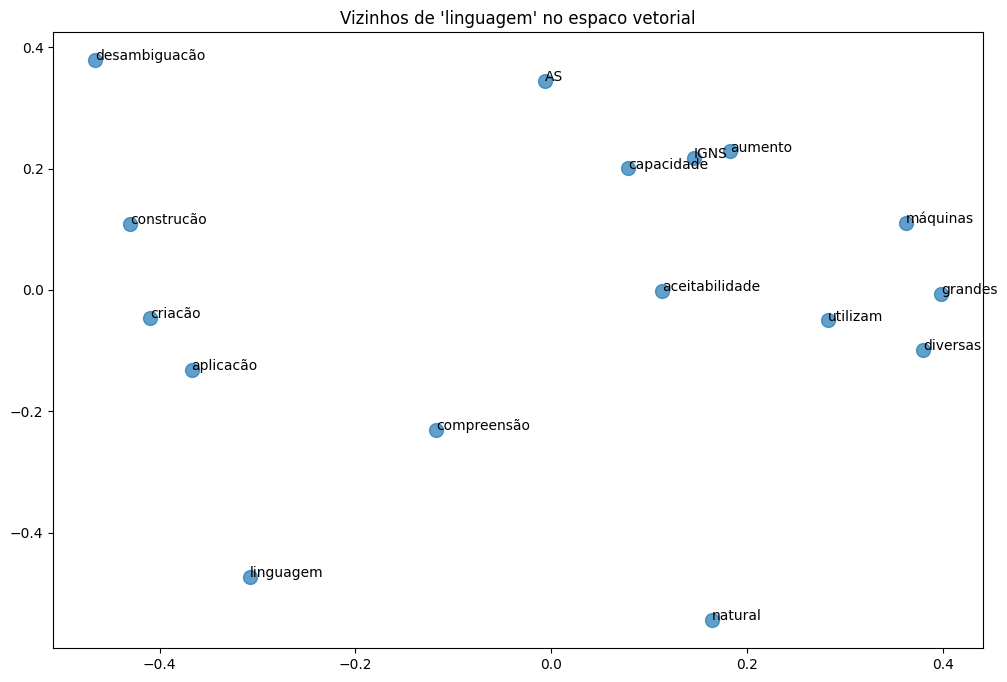


   Comparação entre vetores de palavras relacionadas:
   - 'linguagem': norma = 2.1050
   - 'processamento': norma = 1.9315
   - 'texto': norma = 1.8921
   - 'corpus': norma = 2.5657

   Interpretação: Palavras do mesmo domínio semântico tendem a
   ter normas e direções vetoriais semelhantes.


In [ ]:

# --- Questão 1b: linguagem ---
print("Descrição: Analisando o vetor da palavra 'linguagem' e comparando com outras palavras relacionadas.")

print("\n   Vetor da palavra 'linguagem':")
mostrar_vetor(modelo_w2v, "linguagem")  # Chama a função para exibir o vetor
print("\n\n")
plotar_vizinhos(modelo_w2v, "linguagem", topn=15, titulo="Vizinhos de 'linguagem' no espaco vetorial")

print("\n   Comparação entre vetores de palavras relacionadas:")
palavras_relacionadas = ["linguagem", "processamento", "texto", "corpus"]

for palavra in palavras_relacionadas:  # Percorre cada palavra da lista
    if palavra in modelo_w2v.wv:  # Verifica se a palavra existe no vocabulário
        vetor = modelo_w2v.wv[palavra]  # Obtém o vetor da palavra
        print(f"   - '{palavra}': norma = {np.linalg.norm(vetor):.4f}")  # Calcula e exibe a norma
    else:  # Caso a palavra não exista
        print(f"   - '{palavra}': não encontrada no vocabulário")

print("\n   Interpretação: Palavras do mesmo domínio semântico tendem a")
print("   ter normas e direções vetoriais semelhantes.")

In [ ]:
# --- Questão 1c: substantivo de maior frequência ---
print(f"Descrição: O substantivo '{substantivo_top[0]}' é o que mais aparece no corpus,")
print(f"com {substantivo_top[1]} ocorrências. Seu vetor é:")

mostrar_vetor(modelo_w2v, substantivo_top[0])  # Exibe o vetor do substantivo mais frequente

print(f"\n   Palavras semanticamente relacionadas a '{substantivo_top[0]}':")

if substantivo_top[0] in modelo_w2v.wv:  # Verifica se a palavra existe no vocabulário
    # most_similar retorna lista de (palavra, similaridade)
    similares = modelo_w2v.wv.most_similar(substantivo_top[0], topn=5)

    for palavra, score in similares:  # Percorre cada palavra similar encontrada
        print(f"   - {palavra}: similaridade = {score:.4f}")
else:  # Caso a palavra não exista no vocabulário
    print(f"   Palavra não encontrada no vocabulário do modelo.")


# --- Questão 1d: verbo de maior frequência ---
print(f"Descrição: O verbo '{verbo_top[0]}' é o que mais aparece no corpus,")
print(f"com {verbo_top[1]} ocorrências. Seu vetor é:")

mostrar_vetor(modelo_w2v, verbo_top[0])  # Exibe o vetor do verbo mais frequente

print(f"\n   Palavras semanticamente relacionadas a '{verbo_top[0]}':")

if verbo_top[0] in modelo_w2v.wv:  # Verifica se a palavra existe no vocabulário
    # most_similar retorna lista de (palavra, similaridade)
    similares = modelo_w2v.wv.most_similar(verbo_top[0], topn=5)

    for palavra, score in similares:  # Percorre cada palavra similar encontrada
        print(f"   - {palavra}: similaridade = {score:.4f}")
else:  # Caso a palavra não exista no vocabulário
    print(f"   Palavra não encontrada no vocabulário do modelo.")

Descrição: O substantivo 'anotacão' é o que mais aparece no corpus,
com 247 ocorrências. Seu vetor é:
   Vetor de 'anotacão' (primeiras 10 dimensões):
   [ 0.0259  0.2677 -0.1516 -0.1508 -0.1193  0.1729  0.2315  0.2625 -0.1272
 -0.224 ]
   Norma do vetor (comprimento): 2.5973

   Palavras semanticamente relacionadas a 'anotacão':
   - diretrizes: similaridade = 0.8485
   - dependências: similaridade = 0.8226
   - UD: similaridade = 0.7921
   - esquema: similaridade = 0.7725
   - UDs: similaridade = 0.7702
Descrição: O verbo 'pode' é o que mais aparece no corpus,
com 127 ocorrências. Seu vetor é:
   Vetor de 'pode' (primeiras 10 dimensões):
   [ 0.1137 -0.4341 -0.1651 -0.2439  0.254  -0.104   0.0014 -0.0991 -0.0164
  0.0567]
   Norma do vetor (comprimento): 2.5922

   Palavras semanticamente relacionadas a 'pode':
   - devem: similaridade = 0.8306
   - deve: similaridade = 0.8173
   - vista: similaridade = 0.7942
   - podendo: similaridade = 0.7925
   - poderia: similaridade = 0.7834


In [ ]:
# ============================================================================
# QUESTÃO 2: Termos mais similares
# ============================================================================
print("Descrição: O Word2Vec permite encontrar palavras com vetores mais próximos,")
print("ou seja, palavras que ocorrem em contextos semelhantes no corpus.\n")


# --- Questão 2a: similares a "modelos" ---
similares = palavras_similares(modelo_w2v, "modelos")  # Chama a função para encontrar similares

if similares:  # Verifica se a função retornou resultados (não None)
    print(f"\n   RESULTADO - Top 10 palavras mais similares a 'modelos':")

    # enumerate cria tuplas (índice, valor) começando do 1
    for i, (palavra, score) in enumerate(similares[:10], 1):  # Pega apenas os 10 primeiros
        print(f"   {i:2d}. {palavra}: similaridade = {score:.4f}")

else:  # Caso a palavra não seja encontrada
    print(f"\n   Palavra 'modelos' não encontrada no vocabulário.")


# --- Questão 2b: similares a "linguagem" ---
similares = palavras_similares(modelo_w2v, "linguagem")  # Chama a função para encontrar similares

if similares:  # Verifica se a função retornou resultados
    print(f"\n   RESULTADO - Top 10 palavras mais similares a 'linguagem':")

    for i, (palavra, score) in enumerate(similares[:10], 1):  # Pega apenas os 10 primeiros
        print(f"   {i:2d}. {palavra}: similaridade = {score:.4f}")

else:  # Caso a palavra não seja encontrada
    print(f"\n   Palavra 'linguagem' não encontrada no vocabulário.")


# --- Questão 2c: similares ao substantivo mais frequente ---
print(f"Descrição: Analisando as palavras mais similares ao substantivo")
print(f"mais frequente do corpus: '{substantivo_top[0]}'.")

similares = palavras_similares(modelo_w2v, substantivo_top[0])  # Chama a função para encontrar similares

if similares:  # Verifica se a função retornou resultados
    print(f"\n   RESULTADO - Top 10 palavras mais similares a '{substantivo_top[0]}':")

    for i, (palavra, score) in enumerate(similares[:10], 1):  # Pega apenas os 10 primeiros
        print(f"   {i:2d}. {palavra}: similaridade = {score:.4f}")

else:  # Caso a palavra não seja encontrada
    print(f"\n   Palavra '{substantivo_top[0]}' não encontrada no vocabulário.")


# --- Questão 2d: similares ao verbo mais frequente ---
print("\n" + "-"*60)
print(f"QUESTÃO 2d: Quais termos são mais similares a '{verbo_top[0]}'?")
print("-"*60)
print(f"Descrição: Analisando as palavras mais similares ao verbo")
print(f"mais frequente do corpus: '{verbo_top[0]}'.")

similares = palavras_similares(modelo_w2v, verbo_top[0])  # Chama a função para encontrar similares

if similares:  # Verifica se a função retornou resultados
    print(f"\n   RESULTADO - Top 10 palavras mais similares a '{verbo_top[0]}':")

    for i, (palavra, score) in enumerate(similares[:10], 1):  # Pega apenas os 10 primeiros
        print(f"   {i:2d}. {palavra}: similaridade = {score:.4f}")

else:  # Caso a palavra não seja encontrada
    print(f"\n   Palavra '{verbo_top[0]}' não encontrada no vocabulário.")

Descrição: O Word2Vec permite encontrar palavras com vetores mais próximos,
ou seja, palavras que ocorrem em contextos semelhantes no corpus.


   RESULTADO - Top 10 palavras mais similares a 'modelos':
    1. métodos: similaridade = 0.8636
    2. classificadores: similaridade = 0.8056
    3. grandes: similaridade = 0.8003
    4. baseados: similaridade = 0.7828
    5. vieses: similaridade = 0.7808
    6. comparacão: similaridade = 0.7795
    7. submetidos: similaridade = 0.7750
    8. neurais: similaridade = 0.7741
    9. treinados: similaridade = 0.7689
   10. aprendizado: similaridade = 0.7688

   Interpretação: Palavras como 'abordagens', 'técnicas' e 'métodos'
   são semanticamente próximas de 'modelos' no domínio de PLN.

   RESULTADO - Top 10 palavras mais similares a 'linguagem':
    1. compreensão: similaridade = 0.9108
    2. criacão: similaridade = 0.8969
    3. natural: similaridade = 0.8953
    4. grandes: similaridade = 0.8876
    5. aplicacão: similaridade = 0.8830
    6.

In [ ]:
# ============================================================================
# QUESTÃO 3: Operações de Álgebra Vetorial com Word2Vec
# ============================================================================


print("Descrição: O Word2Vec permite operações algébricas com vetores.")
print("Exemplo clássico: 'rei' - 'homem' + 'mulher' ≈ 'rainha'")
print("Isso demonstra que o modelo captura relações semânticas.\n")


# ==========================================
# FUNÇÃO PARA ANALOGIA (operações vetoriais)
# ==========================================

def analogia(palavra_a, palavra_b, palavra_c, modelo, top_n=10):
    """
    Realiza a operação: palavra_a - palavra_b + palavra_c
    Exemplo: rei - homem + mulher ≈ rainha

    Parametros:
    - palavra_a: primeira palavra (ex: "rei")
    - palavra_b: palavra a ser subtraida (ex: "homem")
    - palavra_c: palavra a ser adicionada (ex: "mulher")
    - modelo: modelo Word2Vec treinado
    - top_n: numero de resultados a mostrar

    Retorna:
    - Lista de tuplas (palavra, similaridade)
    """
    print(f"\n" + "-"*60)
    print(f"OPERAÇÃO: '{palavra_a}' - '{palavra_b}' + '{palavra_c}'")
    print("-"*60)

    # Verifica se as palavras existem no vocabulario
    palavras_faltando = []
    for p in [palavra_a, palavra_b, palavra_c]:
        if p not in modelo.wv:
            palavras_faltando.append(p)

    if palavras_faltando:
        print(f"\n   ATENÇÃO: Palavras não encontradas no vocabulário: {palavras_faltando}")
        print(f"   Exemplos do vocabulário: {', '.join(list(modelo.wv.key_to_index.keys())[:15])}")
        return []

    try:
        # Realiza a operacao de algebra vetorial
        # positive = palavras que somamos, negative = palavras que subtraimos
        resultado = modelo.wv.most_similar(positive=[palavra_a, palavra_c],
                                          negative=[palavra_b],
                                          topn=top_n)

        print(f"\n   RESULTADO - Top {top_n} palavras mais próximas da operação:")
        print("   " + "-"*50)
        for i, (palavra, score) in enumerate(resultado, 1):
            print(f"   {i:2d}. {palavra:<20} (similaridade: {score:.4f})")

        return resultado

    except Exception as e:
        print(f"\n   ERRO na operação: {e}")
        return []


# ==========================================
# FUNÇÃO PARA VER PALAVRAS SIMILARES
# ==========================================

def palavras_similares(palavra, modelo, top_n=10):
    """Encontra as palavras mais similares a uma dada palavra."""
    print(f"\n" + "-"*60)
    print(f"PALAVRAS SIMILARES A: '{palavra}'")
    print("-"*60)

    if palavra not in modelo.wv:
        print(f"\n   ATENÇÃO: Palavra '{palavra}' não encontrada no vocabulário.")
        return []

    try:
        resultado = modelo.wv.most_similar(palavra, topn=top_n)

        print(f"\n   Top {top_n} palavras mais similares:")
        print("   " + "-"*50)
        for i, (p, score) in enumerate(resultado, 1):
            print(f"   {i:2d}. {p:<20} (similaridade: {score:.4f})")

        return resultado

    except Exception as e:
        print(f"\n   ERRO: {e}")
        return []


# ==========================================
# 1. OPERAÇÕES CLÁSSICAS (para validar o modelo)
# ==========================================

print("\n" + "="*60)
print("1. OPERAÇÕES CLÁSSICAS (validação do modelo)")
print("="*60)

# Operações clássicas que funcionam em bons modelos
operacoes_classicas = [
    ("rei", "homem", "mulher"),     # Deve encontrar "rainha"
    ("brasil", "brasileiro", "alemanha"),  # Deve encontrar "alemao"
    ("computador", "programar", "dados"),   # Relação computacional
]

for a, b, c in operacoes_classicas:
    analogia(a, b, c, modelo_w2v, top_n=5)


# ==========================================
# 2. OPERAÇÕES BASEADAS NO SEU CORPUS (PLN)
# ==========================================

print("\n" + "="*60)
print("2. OPERAÇÕES BASEADAS EM PLN (seu corpus)")
print("="*60)

# Operações com termos do seu corpus de artigos
operacoes_pln = [
    # Relações linguísticas
    ("adjetivo", "substantivo", "verbo"),
    ("substantivo", "adjetivo", "verbo"),
    ("sintatica", "dependencia", "semantica"),

    # Relações de Processamento de Linguagem Natural
    ("linguagem", "texto", "imagem"),
    ("texto", "verbal", "imagem"),
    ("processamento", "linguagem", "sentimento"),

    # Relações de análise
    ("analisar", "analise", "classificar"),
    ("classificar", "classificacao", "anotar"),

    # Relações do corpus multimodal
    ("frame", "semantica", "objeto"),
    ("video", "audio", "legenda"),

    # Relações de pesquisa
    ("autor", "pesquisa", "revisor"),
    ("pesquisador", "homem", "mulher"),
]

for a, b, c in operacoes_pln:
    analogia(a, b, c, modelo_w2v, top_n=5)




Descrição: O Word2Vec permite operações algébricas com vetores.
Exemplo clássico: 'rei' - 'homem' + 'mulher' ≈ 'rainha'
Isso demonstra que o modelo captura relações semânticas.


1. OPERAÇÕES CLÁSSICAS (validação do modelo)

------------------------------------------------------------
OPERAÇÃO: 'rei' - 'homem' + 'mulher'
------------------------------------------------------------

   ATENÇÃO: Palavras não encontradas no vocabulário: ['rei']
   Dica: Use palavras que aparecem no seu corpus.
   Exemplos do vocabulário: ,, de, ., a, e, ), o, (, que, em, do, para, da, com, um

------------------------------------------------------------
OPERAÇÃO: 'brasil' - 'brasileiro' + 'alemanha'
------------------------------------------------------------

   ATENÇÃO: Palavras não encontradas no vocabulário: ['brasil', 'alemanha']
   Dica: Use palavras que aparecem no seu corpus.
   Exemplos do vocabulário: ,, de, ., a, e, ), o, (, que, em, do, para, da, com, um

--------------------------------------

In [ ]:
# ==========================================
# 3. EXPLORANDO PALAVRAS ESPECÍFICAS

# Lista de palavras do corpus
palavras_importantes = [
    "linguagem",
    "processamento",
    "adjetivo",
    "substantivo",
    "verbo",
    "frame",
    "corpus",
    "anotacao",
    "sentimento",
    "polaridade",
]

for palavra in palavras_importantes:
    palavras_similares(palavra, modelo_w2v, top_n=8)


# ==========================================
# 4. EXPLORANDO O SUBSTANTIVO MAIS FREQUENTE
# ==========================================

print("\n" + "="*60)
print("4. EXPLORANDO O SUBSTANTIVO MAIS FREQUENTE")
print("="*60)

if todos_substantivos and substantivo_top[0] in modelo_w2v.wv:
    print(f"\nSubstantivo mais frequente: '{substantivo_top[0]}' ({substantivo_top[1]} ocorrências)")
    palavras_similares(substantivo_top[0], modelo_w2v, top_n=10)

    # Tenta analogias com o substantivo mais frequente
    analogia(substantivo_top[0], "palavra", "termo", modelo_w2v, top_n=5)
else:
    print(f"\nSubstantivo '{substantivo_top[0]}' não encontrado no modelo.")


# ==========================================
# 5. EXPLORANDO O VERBO MAIS FREQUENTE
# ==========================================

print("\n" + "="*60)
print("5. EXPLORANDO O VERBO MAIS FREQUENTE")
print("="*60)

if todos_verbos and verbo_top[0] in modelo_w2v.wv:
    print(f"\nVerbo mais frequente: '{verbo_top[0]}' ({verbo_top[1]} ocorrências)")
    palavras_similares(verbo_top[0], modelo_w2v, top_n=10)

    # Tenta analogias com o verbo mais frequente
    analogia(verbo_top[0], "linguagem", "processo", modelo_w2v, top_n=5)
else:
    print(f"\nVerbo '{verbo_top[0]}' não encontrado no modelo.")


------------------------------------------------------------
PALAVRAS SIMILARES A: 'linguagem'
------------------------------------------------------------

   Top 8 palavras mais similares:
   --------------------------------------------------
    1. compreensão          (similaridade: 0.9108)
    2. criacão              (similaridade: 0.8969)
    3. natural              (similaridade: 0.8953)
    4. grandes              (similaridade: 0.8876)
    5. aplicacão            (similaridade: 0.8830)
    6. IGNS                 (similaridade: 0.8824)
    7. diversas             (similaridade: 0.8767)
    8. aumento              (similaridade: 0.8729)

------------------------------------------------------------
PALAVRAS SIMILARES A: 'processamento'
------------------------------------------------------------

   Top 8 palavras mais similares:
   --------------------------------------------------
    1. bancos               (similaridade: 0.9408)
    2. capacidade           (similaridade: 0.